## Column reference

Quick guide to what each field in the spreadsheet means.

| Column | What it contains |
|---|---|
| Goal-Program | Top-level organisational category (e.g. Wildlife, Climate, GCF) |
| Grant | Grant name or identifier |
| Total | Dollar amount of the grant (USD) |
| Funding Type | `Restricted` (donor-earmarked purpose) or `UNR` (unrestricted — WWF discretion) |
| RM Outcome | Numeric rating (1–6) capturing grant outcome quality |
| OG Core Distro | Overhead/core distribution amount for the grant |
| Place-based? | Flag indicating whether the grant is tied to a specific geography |
| IP Country | Country code for place-based grants (Indigenous Peoples / country focus) |
| IP or Country | Broader geography label (IP territory or country name) |
| Project Area | Fine-grained project classification within a Goal-Program |
| Strategic Alignment | Which strategic priority the grant supports |
| Type | Grant instrument type (e.g. grant, sub-grant, contract) |


#### 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

PALETTE = sns.color_palette("muted")
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.edgecolor": "#cccccc",
    "grid.color": "#e0e0e0",
    "axes.titlepad": 12,
})

def fmt_usd(val, _):
    """Compact dollar formatter for axis ticks."""
    if abs(val) >= 1e6:
        return f"${val/1e6:.1f}M"
    elif abs(val) >= 1e3:
        return f"${val/1e3:.0f}K"
    return f"${val:.0f}"

print("Libraries loaded.")

Libraries loaded.


In [2]:
RAW = pd.read_excel("Model Training Data.xlsx")

df = RAW[RAW["Program Totals"].isna()].copy()

df.columns = df.columns.str.strip()

df["Funding Type"] = df["Funding Type"].str.strip()

df.drop(columns=["Unnamed: 15", "Program Totals"], inplace=True, errors="ignore")

print(f"Dataset: {df.shape[0]:,} grant line items × {df.shape[1]} columns")
df.head()

Dataset: 920 grant line items × 14 columns


,Goal-Program,Program,WD Cost Center Hierarchy,Grant,Funding Type,Total,Project Area,Strategic Alignment,Type,Place-based?,IP or Country,RM Outcome,IP Country,OG Core Distro
0,Boundless,725BNDLS Boundless Programming,CC725 President's Office - Boundless,GR004950.14 Ubbens - Boundless - 725,Restricted,42100.00000,Boundless,Other,Leadership Development,NaN,NaN,1.0,NaN,NaN
1,Boundless,725BNDLS Boundless Programming,CC725 President's Office - Boundless,GR012023.01 Nature Network - Trudy Fellowship,Restricted,500000.00000,Boundless,Other,Leadership Development,NaN,NaN,1.0,NaN,NaN
3,Boundless,NATRNTWK Boundless Administration,CC725 President's Office - Boundless,GR004950.14 Ubbens - Boundless - 725,Restricted,50000.00000,Boundless,Other,Leadership Development,NaN,NaN,1.0,NaN,NaN
4,Boundless,NATRNTWK Boundless Administration,CC725 President's Office - Boundless,GR011687.01 Merlin - TA Barron - Nature Networ...,Restricted,620782.40208,Boundless,Other,Leadership Development,NaN,NaN,1.0,NaN,NaN
7,CARE Alliance,9Z138500 CARE Partnership,CC452 People and Conservation,GR000011.01 Uncovered Salaries and Expenses,UNR,150940.45512,CARE Sowing Change,Resilience,Food Security,Not IP Place,Kenya,3.0,NaN,NaN


#### 2. Dataset Overview

Quick sanity check: dimensions, dtypes, and how much of each column is actually populated.

In [3]:
miss = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
miss_df = pd.DataFrame({"Missing %": miss, "Non-null count": df.notnull().sum()})
print(miss_df.to_string())

                          Missing %  Non-null count
Funding Type                    3.8             885
Goal-Program                    0.0             920
Grant                           5.3             871
IP Country                     95.2              44
IP or Country                  64.1             330
OG Core Distro                 97.7              21
Place-based?                   64.1             330
Program                         0.2             918
Project Area                    5.1             873
RM Outcome                     49.7             463
Strategic Alignment             5.0             874
Total                           2.4             898
Type                            7.5             851
WD Cost Center Hierarchy        0.3             917


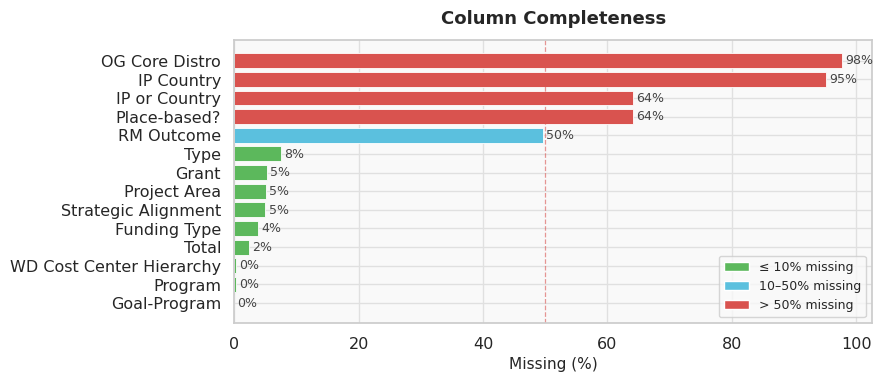

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

colors = ["#d9534f" if v > 50 else "#5bc0de" if v > 10 else "#5cb85c" for v in miss.values]
bars = ax.barh(miss.index[::-1], miss.values[::-1], color=colors[::-1], edgecolor="white", linewidth=0.6)

ax.set_xlabel("Missing (%)", fontsize=11)
ax.set_title("Column Completeness", fontsize=13, fontweight="bold")
ax.axvline(50, color="#d9534f", linestyle="--", linewidth=0.9, alpha=0.6)

for bar, val in zip(bars, miss.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}%", va="center", fontsize=9, color="#444")

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#5cb85c", label="≤ 10% missing"),
    Patch(facecolor="#5bc0de", label="10–50% missing"),
    Patch(facecolor="#d9534f", label="> 50% missing"),
], fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

Takeaways:
- **IP Country**, **OG Core Distro**, **Place-based?**, and **IP or Country** are the sparsest columns (they only apply to place-based grants, which are a subset of the portfolio)
- **RM Outcome**, **Type**, and **Grant** are mostly populated and should be reliable for modeling.
- The **Total** column is nearly complete (only ~2% missing).

#### 3. Portfolio by Goal-Program

In [5]:
goal_summary = (
    df.groupby("Goal-Program")
    .agg(Grants=("Grant", "count"), Total_USD=("Total", "sum"))
    .sort_values("Total_USD", ascending=False)
)
goal_summary["Total_USD_M"] = (goal_summary["Total_USD"] / 1e6).round(2)
goal_summary[["Grants", "Total_USD_M"]].style.background_gradient(cmap="Blues", subset="Total_USD_M").format({"Total_USD_M": "${:.2f}M"})

,Grants,Total_USD_M
Goal-Program,,
Earth for Life/CAI,38,$56.71M
GCF,14,$21.60M
Network Services,1,$19.00M
Oceans,79,$15.23M
Forest,69,$14.08M
COU-Country Office Total,0,$12.24M
COU-Country Office,60,$12.24M
Markets and Food,85,$11.66M
Climate,47,$11.64M


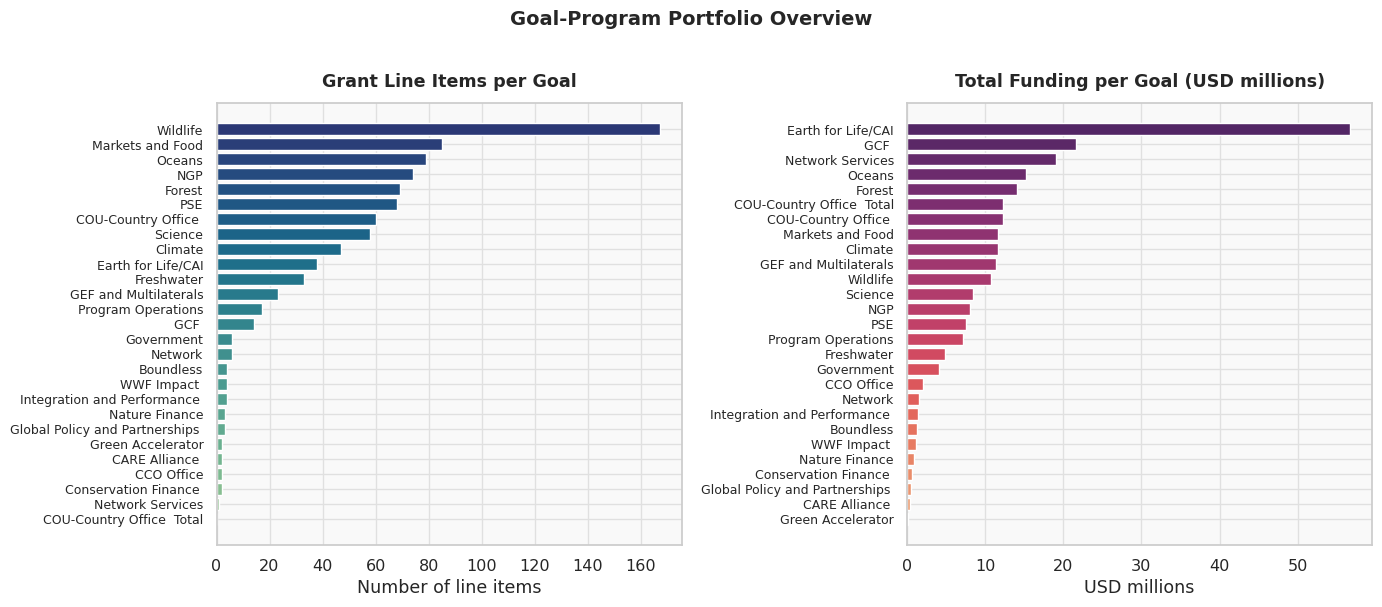

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

goal_by_count = goal_summary.sort_values("Grants")
goal_by_total = goal_summary.sort_values("Total_USD")

axes[0].barh(goal_by_count.index, goal_by_count["Grants"],
             color=sns.color_palette("crest", len(goal_by_count)))
axes[0].set_title("Grant Line Items per Goal", fontweight="bold")
axes[0].set_xlabel("Number of line items")

axes[1].barh(goal_by_total.index, goal_by_total["Total_USD"] / 1e6,
             color=sns.color_palette("flare", len(goal_by_total)))
axes[1].set_title("Total Funding per Goal (USD millions)", fontweight="bold")
axes[1].set_xlabel("USD millions")

for ax in axes:
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Goal-Program Portfolio Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Wildlife has the most individual grant lines, but it's not the highest in total funding per goal.

This gap between volume of grants and dollar weight points to meaningful variation in grant size across goals.

#### 4. Restricted vs. Unrestricted Funding

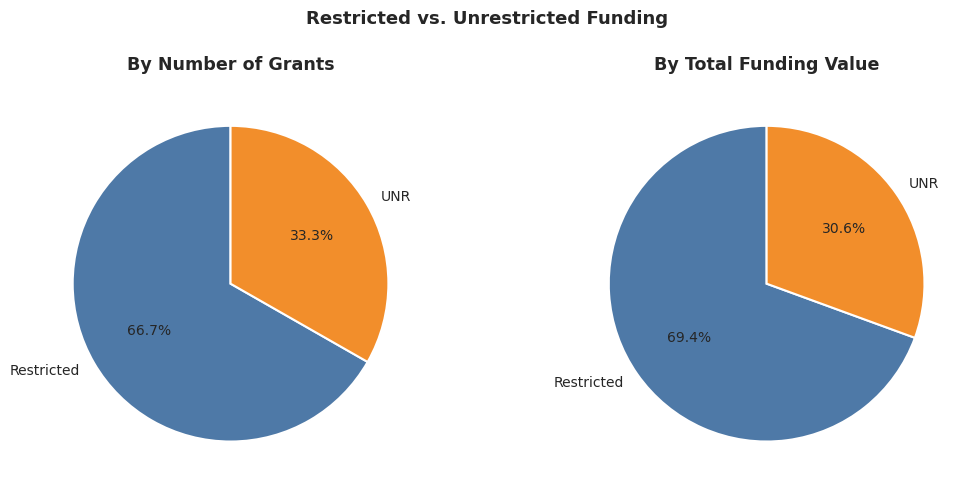

In [7]:
ft = df.dropna(subset=["Funding Type"])
ft_total = ft.groupby("Funding Type")["Total"].sum()
ft_count = ft.groupby("Funding Type")["Total"].count()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

pie_kw = dict(autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10},
              wedgeprops={"edgecolor": "white", "linewidth": 1.5})

axes[0].pie(ft_count, labels=ft_count.index, colors=["#4E79A7", "#F28E2B"], **pie_kw)
axes[0].set_title("By Number of Grants", fontweight="bold")

axes[1].pie(ft_total, labels=ft_total.index, colors=["#4E79A7", "#F28E2B"], **pie_kw)
axes[1].set_title("By Total Funding Value", fontweight="bold")

plt.suptitle("Restricted vs. Unrestricted Funding", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

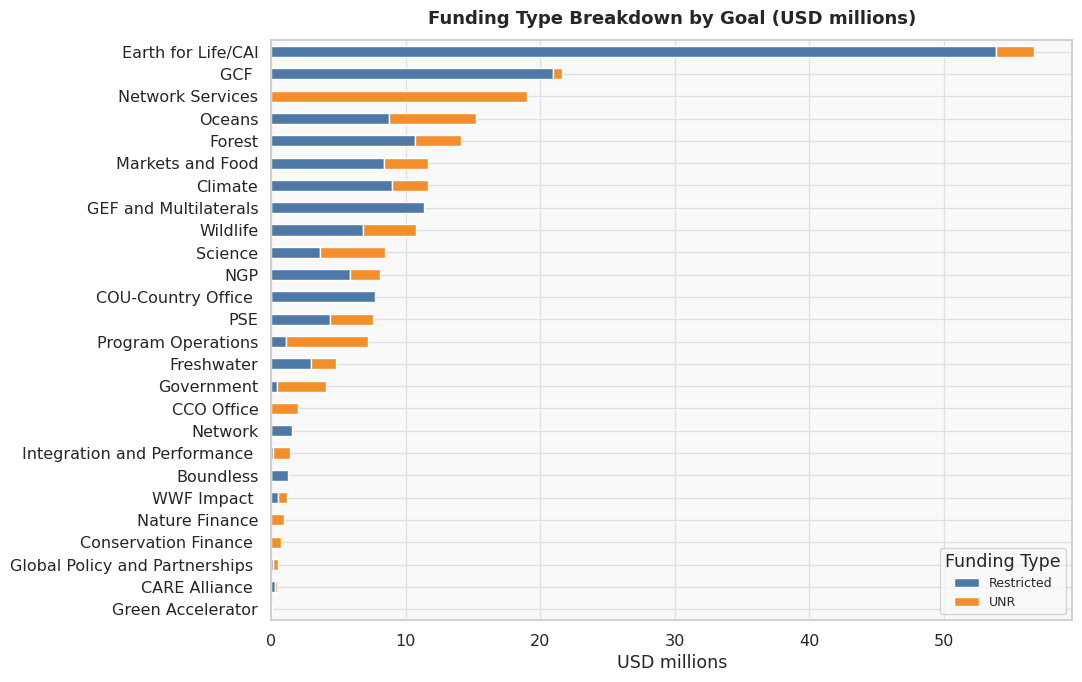

In [8]:
ft_goal = (
    ft.groupby(["Goal-Program", "Funding Type"])["Total"]
    .sum()
    .unstack(fill_value=0)
    .div(1e6)  # to millions
)
ft_goal = ft_goal.loc[ft_goal.sum(axis=1).sort_values().index]

ft_goal.plot(kind="barh", stacked=True, figsize=(11, 7),
             color=["#4E79A7", "#F28E2B"], edgecolor="white")
plt.title("Funding Type Breakdown by Goal (USD millions)", fontweight="bold", fontsize=13)
plt.xlabel("USD millions")
plt.ylabel("")
plt.legend(title="Funding Type", fontsize=9)
plt.tight_layout()
plt.show()

Restricted funding dominates both by count and by dollar value, meaning most grants come with donor-specified conditions.

Some goals (like GCF and GEF and Multilaterals) are entirely restricted, which makes sense given their grant-making structure.

Science and Climate tend to carry a higher unrestricted share, giving those teams more flexibility.


Taken from google:
> Restricted and unrestricted funds represent the two primary categories of income for nonprofit organizations, differing primarily in the level of flexibility and control over how money can be spent
>
>    Restricted Funds: Contributions that must be used for a specific purpose or timeframe defined by the donor or grantor.
>
>    Unrestricted Funds: Contributions that can be used at the organization's discretion for general operations and needs.
>

#### 5. Grant Size Distribution

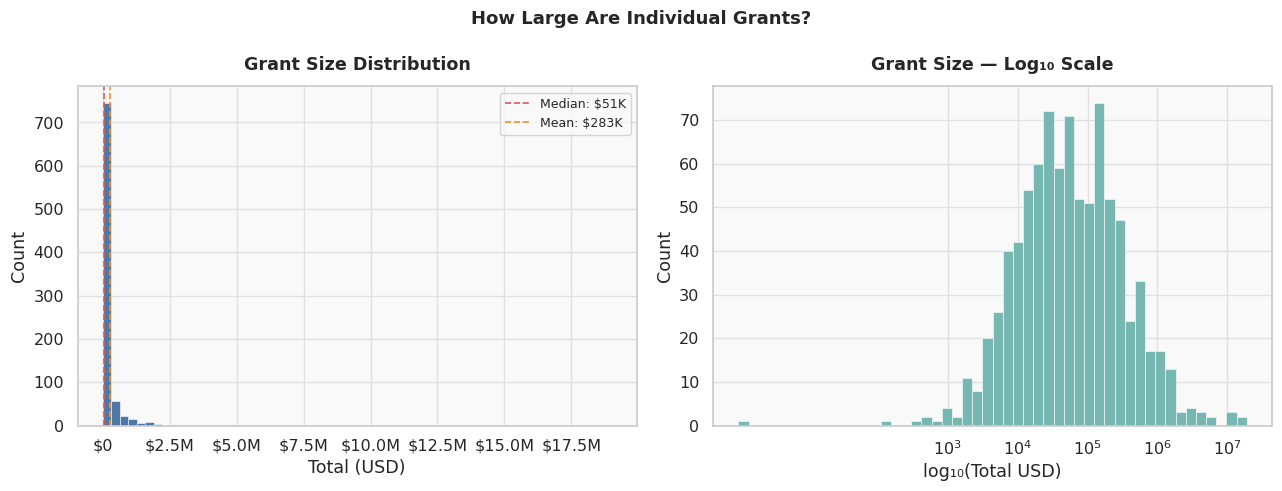

  Min:    $-91K
  Median: $49K
  Mean:   $274K
  Max:    $19.0M
  Negative values: 5 (likely adjustments/reversals)


In [9]:
totals = df["Total"].dropna()
positive = totals[totals > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(positive, bins=60, color="#4E79A7", edgecolor="white", linewidth=0.4)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
axes[0].set_title("Grant Size Distribution", fontweight="bold")
axes[0].set_xlabel("Total (USD)")
axes[0].set_ylabel("Count")
axes[0].axvline(positive.median(), color="#E15759", linestyle="--", linewidth=1.2,
                label=f"Median: {fmt_usd(positive.median(), None)}")
axes[0].axvline(positive.mean(), color="#F28E2B", linestyle="--", linewidth=1.2,
                label=f"Mean: {fmt_usd(positive.mean(), None)}")
axes[0].legend(fontsize=9)

axes[1].hist(np.log10(positive), bins=50, color="#76B7B2", edgecolor="white", linewidth=0.4)
axes[1].set_title("Grant Size — Log₁₀ Scale", fontweight="bold")
axes[1].set_xlabel("log₁₀(Total USD)")
axes[1].set_ylabel("Count")
tick_vals = [3, 4, 5, 6, 7]
axes[1].set_xticks(tick_vals)
axes[1].set_xticklabels([f"$10^{v}$" for v in tick_vals])

plt.suptitle("How Large Are Individual Grants?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"  Min:    {fmt_usd(totals.min(), None)}")
print(f"  Median: {fmt_usd(totals.median(), None)}")
print(f"  Mean:   {fmt_usd(totals.mean(), None)}")
print(f"  Max:    {fmt_usd(totals.max(), None)}")
print(f"  Negative values: {(totals < 0).sum()} (likely adjustments/reversals)")

The distribution is extremely right-skewed: the median hovers around $50K but the mean is pulled well above that by a handful of multi-million dollar grants.

On the log scale, the spread is roughly normal.

(The negative values are most likely accounting adjustments or grant reversals, there are very few and they're small in magnitude)

#### 6. Strategic Alignment & Grant Types

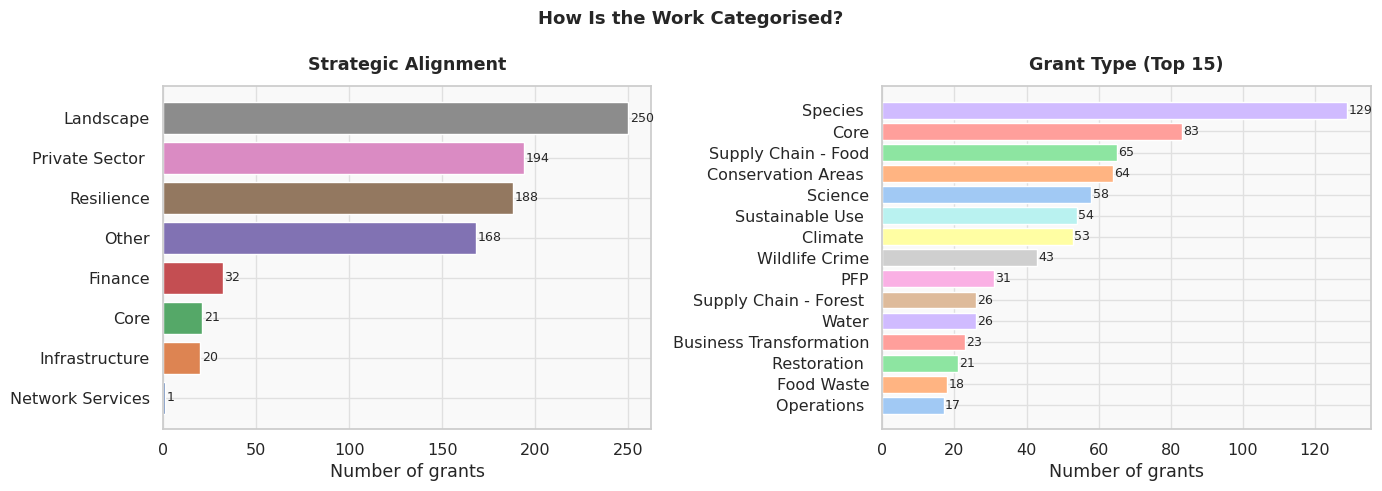

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sa = df["Strategic Alignment"].value_counts()
axes[0].barh(sa.index[::-1], sa.values[::-1], color=sns.color_palette("deep", len(sa)))
axes[0].set_title("Strategic Alignment", fontweight="bold")
axes[0].set_xlabel("Number of grants")
for i, v in enumerate(sa.values[::-1]):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=9)

gt = df["Type"].value_counts().head(15)
axes[1].barh(gt.index[::-1], gt.values[::-1], color=sns.color_palette("pastel", len(gt)))
axes[1].set_title("Grant Type (Top 15)", fontweight="bold")
axes[1].set_xlabel("Number of grants")
for i, v in enumerate(gt.values[::-1]):
    axes[1].text(v + 0.3, i, str(v), va="center", fontsize=9)

plt.suptitle("How Is the Work Categorised?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

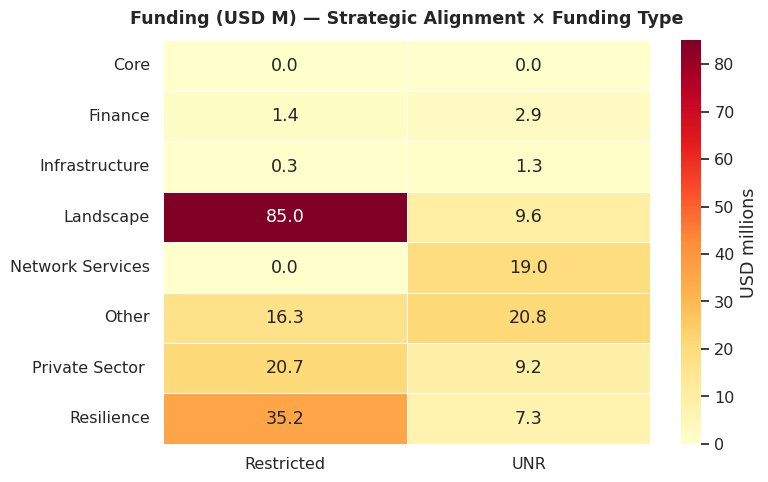

In [11]:
cross = (
    df.dropna(subset=["Strategic Alignment", "Funding Type"])
    .groupby(["Strategic Alignment", "Funding Type"])["Total"]
    .sum()
    .unstack(fill_value=0)
    .div(1e6)
    .round(2)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cross, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "USD millions"}, ax=ax)
ax.set_title("Funding (USD M) — Strategic Alignment × Funding Type", fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Landscape and Private Sector lead in both grant count and dollar value.

The heatmap confirms that Landscape work is heavily restricted.

The Other bucket is large, which is worth cleaning up over time if more precise classification is available.

On grant types, Species work tops the count, followed by organisational Core grants and Supply Chain - Food.

#### 7. RM Outcome Scores

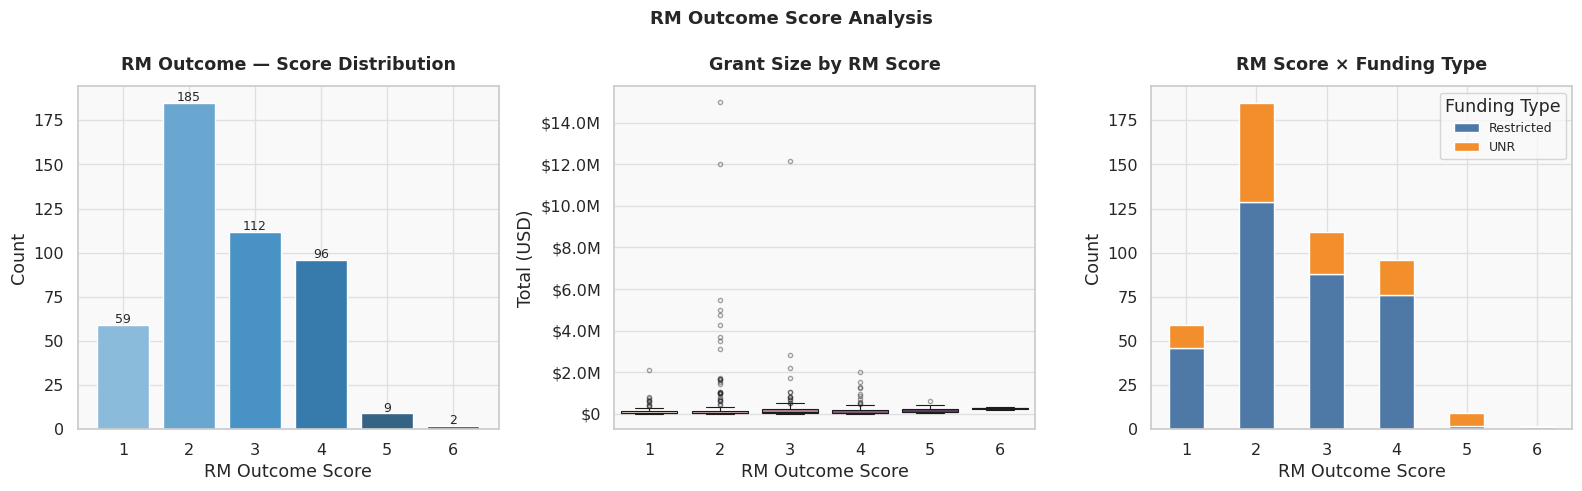

Median grant size by RM score:
RM Outcome
1     $50K
2     $55K
3     $91K
4     $48K
5     $79K
6    $250K
Name: Total, dtype: object


In [12]:
rm = df.dropna(subset=["RM Outcome"]).copy()
rm["RM Outcome"] = rm["RM Outcome"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rm_counts = rm["RM Outcome"].value_counts().sort_index()
axes[0].bar(rm_counts.index, rm_counts.values,
            color=sns.color_palette("Blues_d", len(rm_counts)), edgecolor="white")
axes[0].set_title("RM Outcome — Score Distribution", fontweight="bold")
axes[0].set_xlabel("RM Outcome Score")
axes[0].set_ylabel("Count")
for x, y in zip(rm_counts.index, rm_counts.values):
    axes[0].text(x, y + 1, str(y), ha="center", fontsize=9)

sns.boxplot(data=rm[rm["Total"] > 0], x="RM Outcome", y="Total",
            hue="RM Outcome", legend=False, linewidth=0.8,
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
            ax=axes[1])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
axes[1].set_title("Grant Size by RM Score", fontweight="bold")
axes[1].set_xlabel("RM Outcome Score")
axes[1].set_ylabel("Total (USD)")

rm_ft = (
    rm.dropna(subset=["Funding Type"])
    .groupby(["RM Outcome", "Funding Type"])
    .size()
    .unstack(fill_value=0)
)
rm_ft.plot(kind="bar", stacked=True, ax=axes[2],
           color=["#4E79A7", "#F28E2B"], edgecolor="white")
axes[2].set_title("RM Score × Funding Type", fontweight="bold")
axes[2].set_xlabel("RM Outcome Score")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Funding Type", fontsize=9)

plt.suptitle("RM Outcome Score Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Median grant size by RM score:")
print(rm[rm["Total"] > 0].groupby("RM Outcome")["Total"].median().apply(lambda x: fmt_usd(x, None)))


Scores cluster between 2 and 4, and very few grants hit the extremes.

There's no strong monotonic relationship between RM score and grant size, suggesting the score captures something other than sheer dollar magnitude (maybe programmatic impact or strategic priority.)

#### 8. Place-Based Grant Geography

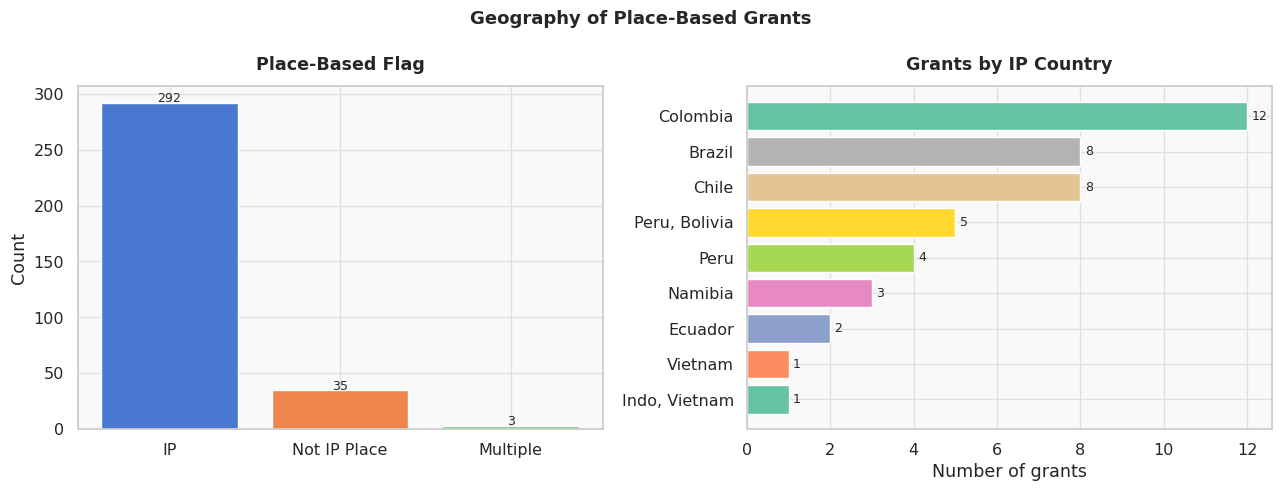

330 of 920 line items are place-based (35.9%)


In [13]:
pb = df.dropna(subset=["Place-based?"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pb_counts = pb["Place-based?"].str.strip().value_counts()
axes[0].bar(pb_counts.index, pb_counts.values,
            color=sns.color_palette("muted", len(pb_counts)), edgecolor="white")
axes[0].set_title("Place-Based Flag", fontweight="bold")
axes[0].set_ylabel("Count")
for x, y in zip(range(len(pb_counts)), pb_counts.values):
    axes[0].text(x, y + 0.5, str(y), ha="center", fontsize=9)

country_data = df.dropna(subset=["IP Country"])
country_counts = country_data["IP Country"].str.strip().value_counts()
axes[1].barh(country_counts.index[::-1], country_counts.values[::-1],
             color=sns.color_palette("Set2", len(country_counts)))
axes[1].set_title("Grants by IP Country", fontweight="bold")
axes[1].set_xlabel("Number of grants")
for i, v in enumerate(country_counts.values[::-1]):
    axes[1].text(v + 0.1, i, str(v), va="center", fontsize=9)

plt.suptitle("Geography of Place-Based Grants", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

place_pct = len(pb) / len(df) * 100
print(f"{len(pb)} of {len(df)} line items are place-based ({place_pct:.1f}%)")

Only ~35% of grants carry a place-based flag, and **IP Country** is populated for far fewer still.

The small country sample suggests that **IP Country** is likely used for a specific sub-programme rather than all place-based work.

#### 9. Top Project Areas

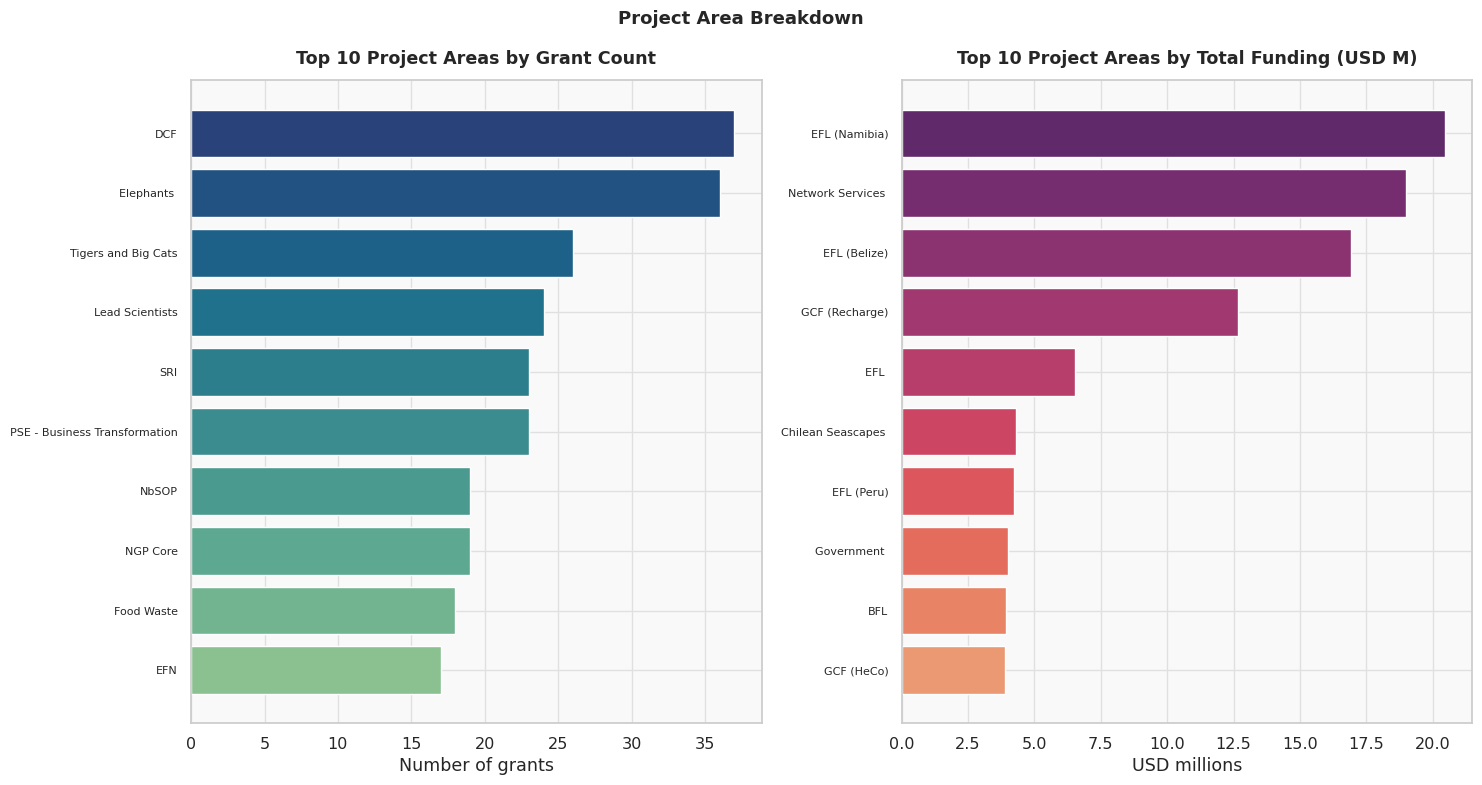

In [22]:
TOP_N = 10
pa = df.dropna(subset=["Project Area", "Total"])
pa_count = pa["Project Area"].value_counts().head(TOP_N)
pa_total = pa.groupby("Project Area")["Total"].sum().sort_values(ascending=False).head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].barh(pa_count.index[::-1], pa_count.values[::-1],
             color=sns.color_palette("crest", TOP_N))
axes[0].set_title(f"Top {TOP_N} Project Areas by Grant Count", fontweight="bold")
axes[0].set_xlabel("Number of grants")

axes[1].barh(pa_total.index[::-1], pa_total.values[::-1] / 1e6,
             color=sns.color_palette("flare", TOP_N))
axes[1].set_title(f"Top {TOP_N} Project Areas by Total Funding (USD M)", fontweight="bold")
axes[1].set_xlabel("USD millions")

for ax in axes:
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Project Area Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

DCF (Diverse Conservation Finance), Elephants, and Tigers and Big Cats rank among the busiest project areas by grant count.

The dollar-weighted ranking can look quite different, a single large grant to a project area will move it up the funding ladder even if it has few line items.

#### 10. Numeric Variable Correlations

A quick look at how the numeric fields relate to each other.

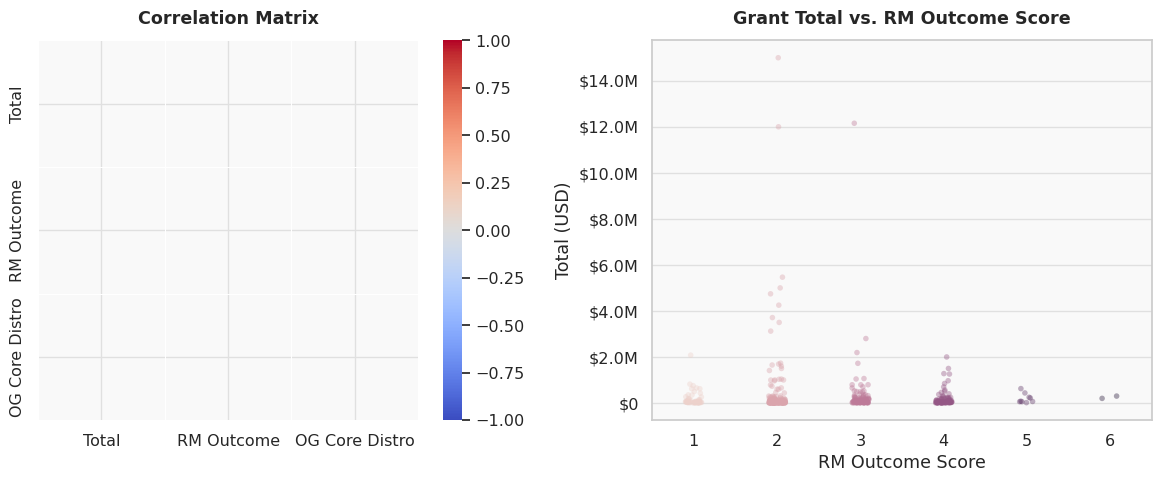

In [23]:
numeric_cols = ["Total", "RM Outcome", "OG Core Distro"]
corr_df = df[numeric_cols].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

corr_mat = corr_df.corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            mask=mask, ax=axes[0], square=True)
axes[0].set_title("Correlation Matrix", fontweight="bold")

plot_df = df.dropna(subset=["RM Outcome", "Total"]).copy()
plot_df = plot_df[plot_df["Total"] > 0]
plot_df["RM Outcome"] = plot_df["RM Outcome"].astype(int)
sns.stripplot(data=plot_df, x="RM Outcome", y="Total",
              jitter=True, alpha=0.4, size=4,
              hue="RM Outcome", legend=False, ax=axes[1])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
axes[1].set_title("Grant Total vs. RM Outcome Score", fontweight="bold")
axes[1].set_xlabel("RM Outcome Score")
axes[1].set_ylabel("Total (USD)")

plt.tight_layout()
plt.show()


No strong linear correlations jump out :(
    
**Total** and **RM Outcome** are effectively uncorrelated, confirming that the rating is capturing qualitative/strategic dimensions rather than just rewarding the biggest grants.